## KinTree (Kinetic Interaction Tree)
#### KinTREE is a decision tree based model that is able to caputre kinetic interaction rules from molecular dynamics simulations
Workflow Overview
1. Feature Extraction: Transform raw MD simulation trajectories into structured interaction data.
2. Model Training: Construct the KinTree to map the system's kinetic hierarchy.
3. Validation and Kinetic Analysis: Assess model robustness and statistical consistency.
4. Structural Visualization:
    - Tree Construction: Visualize the hierarchical relationship between metastable states.
    - Cluster Networks: Map the specific interaction networks defining each structural cluster.

This handbook provides a general workflow to study a ligand-protein binding complex.

### Step 1 Feature Extraction
This session preprocesses the data and prepares the input ready for the model. This includes:
1. **Sanity Checks**: Check whether the protontion states are correct, whether all residues have been defined by atom masks and stand amino acids list.
2. **Trajectory Alignment (Optional)**
3. **Trajectory Striding (Optional)**
2. **Calculation of the Contact map**
3. **Calculation of the Interaction network**
4. **Generate inputs**

In [2]:
import warnings
warnings.filterwarnings('ignore')
from Interaction_Detect import *
import MDAnalysis as mda
from MDAnalysis.analysis import align
from glob import glob
import torch

#### Critical Warning: Protonation States
Some molecular dynamics engines occasionally maintain standard residue names (e.g., **GLU**, **ASP**, or **CYS**) even after protonation changes. Since KinTree defines **atom masks** strictly based on these residue names, a mismatch will lead to incorrect interaction data.

Before proceeding, ensure your **protonation states align with your residue names.**

To facilitate this check, we provide the following checking function to validate your system. Things you should know for this function:
1. **Keep Hydrogens**: Your topology file must include hydrogen atoms
2. **Raw MD Output**: You can use the direct toplogy output from you simulation (including membrane components or solvent/salts). The function will filter for the relevant residues.

**Recommended Action**
Run the following cell to audit your topology. If the function flags a mismatch, you must either **update your residue names** in the .pdb/.gro file.

**Note that you might need to alter the function to suits your system**

In [2]:
def check_protonation_name_consistency(universe, selection="protein", verbose=True):
    """
    Check whether residue protonation state inferred from atom presence
    is consistent with residue name. Emits warnings (forced visible) and
    returns a list of mismatches.

    Parameters
    ----------
    universe : MDAnalysis.Universe
    selection : str
        Atom selection to scan (default "protein")
    verbose : bool
        Print a short summary + each mismatch line

    Returns
    -------
    mismatches : list[dict]
        Each dict contains segid, resid, resname, issue, details
    """
    ag = universe.select_atoms(selection)
    mismatches = []

    def record(res, issue, details):
        d = {
            "segid": str(res.segid),
            "resid": int(res.resid),
            "resname": str(res.resname),
            "issue": issue,
            "details": details,
        }
        mismatches.append(d)

    # Force warnings to show even in notebooks
    with warnings.catch_warnings():
        warnings.simplefilter("always", UserWarning)

        for res in ag.residues:
            resname = res.resname.strip()
            atom_names = {a.name.strip() for a in res.atoms}

            # ---- ASP / ASH: detect sidechain acidic H as HD1/HD2 (ignore HB*, HA, etc.) ----
            if resname in {"ASP", "ASH"}:
                has_sidechain_HD = any(n in atom_names for n in ("HD1", "HD2"))

                if resname == "ASP" and has_sidechain_HD:
                    msg = f"ASP has sidechain proton {sorted(set(atom_names)&{'HD1','HD2'})} but resname is ASP (expected ASH)"
                    warnings.warn(f"{msg} @ segid={res.segid}, resid={res.resid}", UserWarning)
                    record(res, "ASP_named_but_protonated", msg)

                if resname == "ASH" and not has_sidechain_HD:
                    msg = "ASH has no sidechain proton (HD1/HD2 missing) but resname is ASH (expected ASP)"
                    warnings.warn(f"{msg} @ segid={res.segid}, resid={res.resid}", UserWarning)
                    record(res, "ASH_named_but_deprotonated", msg)

            # ---- GLU / GLH: detect sidechain acidic H as HE1/HE2 ----
            if resname in {"GLU", "GLH"}:
                has_sidechain_HE = any(n in atom_names for n in ("HE1", "HE2"))

                if resname == "GLU" and has_sidechain_HE:
                    msg = f"GLU has sidechain proton {sorted(set(atom_names)&{'HE1','HE2'})} but resname is GLU (expected GLH)"
                    warnings.warn(f"{msg} @ segid={res.segid}, resid={res.resid}", UserWarning)
                    record(res, "GLU_named_but_protonated", msg)

                if resname == "GLH" and not has_sidechain_HE:
                    msg = "GLH has no sidechain proton (HE1/HE2 missing) but resname is GLH (expected GLU)"
                    warnings.warn(f"{msg} @ segid={res.segid}, resid={res.resid}", UserWarning)
                    record(res, "GLH_named_but_deprotonated", msg)

            # ---- Histidine: check tautomer consistency when named (skip plain HIS) ----
            if resname in {"HID", "HSD", "HIE", "HSE", "HIP", "HSP"}:
                has_HD1 = "HD1" in atom_names
                has_HE2 = "HE2" in atom_names

                expected = {
                    "HID": (True,  False),
                    "HSD": (True,  False),
                    "HIE": (False, True ),
                    "HSE": (False, True ),
                    "HIP": (True,  True ),
                    "HSP": (True,  True ),
                }[resname]

                found = (has_HD1, has_HE2)
                if found != expected:
                    msg = f"{resname} expected (HD1,HE2)={expected} but found {found}"
                    warnings.warn(f"{msg} @ segid={res.segid}, resid={res.resid}", UserWarning)
                    record(res, "HIS_tautomer_mismatch", msg)

            # ---- CYS / CYM: thiol proton HG ----
            # ---------- CYS / CYM / CYX ----------
            # ---------- CYS / CYM / CYX ----------
            if resname in {"CYS", "CYM", "CYX"}:
                has_thiol_H = any(a.name.startswith("HG") for a in res.atoms)

                if resname == "CYS" and not has_thiol_H:
                    msg = "CYS without thiol proton (may be CYM or CYX)"
                    warnings.warn(
                        f"{msg} (segid={res.segid}, resid={res.resid})",
                        UserWarning
                    )
                    record(res, "CYS_named_but_deprotonated", msg)

                if resname == "CYM" and has_thiol_H:
                    msg = "CYM with thiol proton (should be CYS)"
                    warnings.warn(
                        f"{msg} (segid={res.segid}, resid={res.resid})",
                        UserWarning
                    )
                    record(res, "CYM_named_but_protonated", msg)

                if resname == "CYX" and has_thiol_H:
                    msg = "CYX with thiol proton (disulfide cysteine should not have HG)"
                    warnings.warn(
                        f"{msg} (segid={res.segid}, resid={res.resid})",
                        UserWarning
                    )
                    record(res, "CYX_named_but_protonated", msg)



    if verbose:
        if mismatches:
            print(f"[protonation-name check] mismatches: {len(mismatches)}")
            for m in mismatches:
                print(f"  {m['segid']}:{m['resid']} {m['resname']} | {m['issue']} | {m['details']}")
        else:
            print("[protonation-name check] no mismatches found.")

    return mismatches

In [4]:
### example usage
u = mda.Universe('./data/structure_with_chains.pdb')
check_protonation_name_consistency(u)

[protonation-name check] no mismatches found.


[]

**Handling Protonation Mismatches**
If you see any mismatch in the previous cell, you must manually correct your topology with the expectd namings. Failure to do so will result in an inaccurate interaction detection.

**Step-by-Step Correction**
1. **Identify the Residue**: Note the residue ID and atom names flagged by the function. The residue ID provided by the function is the actualy ID in the pdb.
2. **Edit the Topology**: Open your topology file (e.g., .pdb, .gro, or .psf) in a text editor.
3. **Rename the Residue**: Locate the specific residue and change its name to the kinetically correct version.
    Example: If you have a deprotonated Cysteine involved in a disulfide bond, change CYS to CYX.
4. **Re-Verify**: Save the file and run the checking function again to confirm the error is resolved.

Note: If you only have a topology without hydrogen, then you have no choice but trust current protonation names.

In [49]:
# u = mda.Universe('./data/filtered.pdb')
# check_protonation_name_consistency(u)

#### Optional: Multi-Trajectory Alignment
The core KinTree workflow is optimized for a single trajectory. If your dataset contains **multiple trajectories**, you must **align them to a common reference frame** to ensure spatial consistency across all interaction data.

The following utility aligns each of your trajectories to a specified reference structure (e.g., a starting crystal structure or a representative frame).

In [8]:
# --- Step 1. Specify paths ---
# Use the updated topology from here
topology = './L1_new_TRAJ/filtered.pdb'
# Detect all trajectory files (can include subfolders)
trajectory_files = sorted(glob('./L1_new_TRAJ/*.xtc'))  # or './Data/*.xtc' if flat folder

print(f"Detected {len(trajectory_files)} trajectories:")

Detected 2126 trajectories:


In [3]:
import random
# Define the Reference structure
reference = mda.Universe(topology)

# List of short trajectories
traj_files = random.sample(trajectory_files, 50)  # Replace with your file names

# Initialize writer for the combined trajectory
n_atoms = reference.atoms.n_atoms
writer = mda.Writer("./Aligned.xtc", n_atoms)

traj_lengths = []
for traj in traj_files:
    # Load trajectory
    u = mda.Universe(topology, traj)
    traj_lengths.append(len(u.trajectory))

    # Align trajectory to the reference
    ref_atoms = reference.select_atoms("protein")  # Adjust selection if needed
    mobile_atoms = u.select_atoms("protein")

    # Create alignment object
    alignment = align.AlignTraj(u, reference, select="protein", in_memory=True)
    alignment.run()

    # Write aligned frames to the combined trajectory
    for ts in u.trajectory:
        writer.write(u.atoms)

# Close the writer
writer.close()

print(f"Lengths: {traj_lengths}")
print(f"Total frames: {sum(traj_lengths)}")

Lengths: [500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500]
Total frames: 25000


**Preserving Trajectory Boundaries**\
When concatenating multiple simulation replicas, the trajectory length (frame count) for each individual run is stored as a metadata reference. This prevents the model from incorrectly assuming a physical transition exists between the last frame of "Trajectory A" and the first frame of "Trajectory B."

In [4]:
with open('./traj_lengths.pkl', 'wb') as fp:
    pickle.dump(traj_lengths, fp)

#### Topology Validation and Atom Masking
Before running the interaction analysis, we must verify that every residue in your topology is recognized by the KinTree atom masks. This step ensures no chemical interactions are missed due to naming mismatches.

In [5]:
topology = './L1_new_TRAJ/filtered.pdb'
trajectory = './Aligned.xtc'

In [56]:
validate_topology(topology,atom_masks)

Validating topology: ./L1_new_TRAJ/filtered.pdb...

!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
CRITICAL ERROR: MISSING ATOM MASKS
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
The following residues were found in './L1_new_TRAJ/filtered.pdb' but are NOT defined in your atom_masks:

   MISSING: HE2, HD9, K+, HD8, HD5, ZN6, AP2, ZN9, HD4

Your model will ignore these residues completely if you proceed.
Please run 'user_define_ligand_masks()' or update the dictionary manually.
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!



ValueError: Undefined residues found: ['HE2', 'HD9', 'K+', 'HD8', 'HD5', 'ZN6', 'AP2', 'ZN9', 'HD4']

If the function returns a list of "undefined" residues, do not be alarmed.\
    - **Engine-Specific Naming**: KinTree’s default masks use AMBER nomenclature.\
    - **CHARMM/GROMOS Support**: If you are using a different force field, residues like Histidine might be named differently (e.g., HSD instead of HID).\
    - **Ligand**: Our model can work with ligand, but the ligand has not yet defined.
We define these names one by one. First, for amino acids, you can map residue names to existing definitions without rewriting the underlying logic. This "aliasing" ensures the engine treats them identically.

In [57]:
atom_masks['HD8'] = atom_masks["HID"]
atom_masks['HD9'] = atom_masks["HID"]
atom_masks['HD4'] = atom_masks["HID"]
atom_masks['HD5'] = atom_masks["HID"]
atom_masks['HE2'] = atom_masks["HIE"]
atom_masks['AP2'] = atom_masks["ASP"]

Then we define the atom mask for the ligand. Since the later on interaction calculation is completely based on the defined atom mask, user should always be careful and double check the chemical property of their ligands.

In [58]:
# User define the ligand mask
my_ligand_masks = user_define_ligand_masks()
atom_masks.update(my_ligand_masks)

      INTERACTIVE LIGAND MASK GENERATOR
Instructions: Enter atom names separated by commas (e.g., N1, N3).
If a category is empty, just press ENTER.
------------------------------------------------------------

--- Defining Ligand 1 ---
✔ Successfully added K+

--- Defining Ligand 2 ---
✔ Successfully added ZN6

--- Defining Ligand 3 ---
✔ Successfully added ZN9
Generation Complete.


You can save the atom mask for next time usage

In [59]:
for res in list(atom_masks.keys()):
    # Iterate over copy of keys so we can delete while iterating
    for category in list(atom_masks[res].keys()):
        if not atom_masks[res][category]:  # Checks if list is empty []
            del atom_masks[res][category]  # Remove the key entirely

print("Atom masks cleaned: Empty categories removed.")

Atom masks cleaned: Empty categories removed.


In [60]:
save_masks(atom_masks)

Successfully saved masks to atom_masks.json


In [3]:
atom_masks = load_masks('./atom_masks.json')

Successfully loaded 36 masks from ./atom_masks.json


In [4]:
atom_masks

{'ARG': {'donors': ['NE', 'NH1', 'NH2', 'N'],
  'acceptors': ['O'],
  'cation': ['CZ', 'NH1', 'NH2']},
 'LYS': {'donors': ['NZ', 'N'], 'acceptors': ['O'], 'cation': ['NZ']},
 'HIS': {'donors': ['ND1', 'NE2', 'N'],
  'acceptors': ['ND1', 'NE2', 'O'],
  'aromatic': ['CG', 'ND1', 'CD2', 'CE1', 'NE2']},
 'HID': {'donors': ['ND1', 'N'],
  'acceptors': ['NE2', 'O'],
  'aromatic': ['CG', 'ND1', 'CD2', 'CE1', 'NE2']},
 'HIE': {'donors': ['NE2', 'N'],
  'acceptors': ['ND1', 'O'],
  'aromatic': ['CG', 'ND1', 'CD2', 'CE1', 'NE2']},
 'HIP': {'donors': ['ND1', 'NE2', 'N'],
  'acceptors': ['O'],
  'aromatic': ['CG', 'ND1', 'CD2', 'CE1', 'NE2'],
  'cation': ['ND1', 'NE2']},
 'ASP': {'donors': ['N'],
  'acceptors': ['OD1', 'OD2', 'O'],
  'anion': ['OD1', 'OD2']},
 'ASH': {'donors': ['OD1', 'N'], 'acceptors': ['OD2', 'O']},
 'GLU': {'donors': ['N'],
  'acceptors': ['OE1', 'OE2', 'O'],
  'anion': ['OE1', 'OE2']},
 'GLH': {'donors': ['OE1', 'N'], 'acceptors': ['OE2', 'O']},
 'ASN': {'donors': ['ND2', 'N'

After mapping your force-field-specific residues, you must add them to the STANDARD_AMINO_ACIDS list.

This step is critical because the KinTree engine uses this list to identify protein backbone atoms. By default, the model filters out backbone-backbone interactions, as these are often ubiquitous and less "kinetically sensitive" than the side-chain interactions that drive specific conformational transitions.

In [5]:
# Check the current standard amino acid
STANDARD_AMINO_ACIDS

{'ALA',
 'ARG',
 'ASH',
 'ASN',
 'ASP',
 'CYM',
 'CYS',
 'CYX',
 'GLH',
 'GLN',
 'GLU',
 'GLY',
 'HID',
 'HIE',
 'HIP',
 'HIS',
 'ILE',
 'LEU',
 'LYS',
 'MET',
 'PHE',
 'PRO',
 'SER',
 'THR',
 'TRP',
 'TYR',
 'VAL'}

In [6]:
# Update if you have defined any amino acid names (like HSD)
# Just add to the set directly
AA = ['AP2', 'HD8', 'HD9', 'HD4', 'HD5', 'HE2']
for element in AA:
    STANDARD_AMINO_ACIDS.add(element)
STANDARD_AMINO_ACIDS

{'ALA',
 'AP2',
 'ARG',
 'ASH',
 'ASN',
 'ASP',
 'CYM',
 'CYS',
 'CYX',
 'GLH',
 'GLN',
 'GLU',
 'GLY',
 'HD4',
 'HD5',
 'HD8',
 'HD9',
 'HE2',
 'HID',
 'HIE',
 'HIP',
 'HIS',
 'ILE',
 'LEU',
 'LYS',
 'MET',
 'PHE',
 'PRO',
 'SER',
 'THR',
 'TRP',
 'TYR',
 'VAL'}

**Essential! Check again moving forward**

In [9]:
validate_topology(topology,atom_masks)

Validating topology: ./L1_new_TRAJ/filtered.pdb...
✔ Topology Validation Passed: All residues are defined.


True

#### Optional: Striding Long Trajectories
For systems with high atom counts or long simulation times, striding the trajectory can significantly accelerate the interaction detection and model training phases without losing the essential kinetic landscape.

In [ ]:
import MDAnalysis as mda
import pickle

# --- Inputs ---
topology = topology
trajectory = "./Aligned.xtc"
stride = 5

# --- Load original trajectory lengths ---
with open('./traj_lengths.pkl', 'rb') as fp:
    traj_lengths = pickle.load(fp)

# --- Create universe and writer ---
u = mda.Universe(topology, trajectory)

# --- Write strided trajectory ---
with mda.Writer("./Strided_MT1_prot.xtc", u.atoms.n_atoms) as W:
    for ts in u.trajectory[::stride]:
        W.write(u.atoms)

# --- Save new traj_lengths (just integer division) ---
traj_lengths_strided = [L // stride for L in traj_lengths]

with open("./traj_lengths_strided.pkl", "wb") as f:
    pickle.dump(traj_lengths_strided, f)

print("✅ Saved strided trajectory and 'traj_lengths_strided.pkl'")

In [10]:
# --- Load current trajectory lengths ---
with open('./traj_lengths.pkl', 'rb') as fp:
    traj_lengths = pickle.load(fp)

#### Calculation of Contact map and Interaction network with **Ligand**
This session converts raw coordinates into a kinetic feature set by mapping residue-to-residue contacts.

1. **Benchmarking**: Determine the maximum batch size your hardware (GPU/RAM) can handle to optimize processing speed.

2. **Soft Contact Map**: Instead of binary cutoffs, we assign a continuous soft score to each pair. This captures subtle conformational fluctuations that rigid thresholds miss.

3. **Interaction Network**: Construct a weighted network using these scores. The previously defined atom_masks and STANDARD_AMINO_ACIDS are applied here to filter out backbone noise.

4. **Model Input**: Flatten the network tensors into a structured format.

In [11]:
# Speicfy the path to your topology file and trajectory file
trajectory = "./Aligned.xtc"
u = mda.Universe(topology, trajectory)
n_frames = len(u.trajectory)

if n_frames != sum(traj_lengths):
    print(f"ERROR: Total frames in Aligned.xtc ({n_frames}) does not match "
          f"sum of individual traj lengths ({sum(traj_lengths)})!")
else:
    print(f"Frame count OK: {n_frames} frames total.")

Frame count OK: 25000 frames total.


In [10]:
# Test the optimal batch size based on your resources
optimal_batch = find_max_batch_size(topology, trajectory, max_frames=n_frames)
print(f"Using batch size: {optimal_batch}")

Finding maximum batch size...
Testing batch size: 50
Testing batch size: 100
Testing batch size: 200
Testing batch size: 400
Testing batch size: 800
Batch size 800 failed: Unable to allocate 95.1 GiB for an array with shape (800, 31910685) and data type float32
✔ Maximum safe batch size: 400
Using batch size: 400


In [12]:
# Conduct the contact_map for the whole protein
# 40min for a 60000 frame trajecotry of a protein with 450 residues on AMD 5000 Series CPU
# --- Step 3. Compute contacts for all trajectories ---
# if you want to consider any water or ions. you need to specify their name in ligand_names variable!
os.makedirs('./data', exist_ok=True)
filtered_pairs_all = contact_map(
    topology=topology,
    trajectory=trajectory,
    batch_size=200,
    #ligand_names='CHL1', # Define your ligand here,
    outputpath='./data/contact_map_softcontacts.pkl'
)

print("\n✅ Contact map calculation complete.")
print("Trajectory lengths:", traj_lengths)
print("Total frames:", sum(traj_lengths))

Start calculating contacts (Hybrid + Soft Scores)...
Chunk 1: Frames 1 to 200 done
Chunk 2: Frames 201 to 400 done
Chunk 3: Frames 401 to 600 done
Chunk 4: Frames 601 to 800 done
Chunk 5: Frames 801 to 1000 done
Chunk 6: Frames 1001 to 1200 done
Chunk 7: Frames 1201 to 1400 done
Chunk 8: Frames 1401 to 1600 done
Chunk 9: Frames 1601 to 1800 done
Chunk 10: Frames 1801 to 2000 done
Chunk 11: Frames 2001 to 2200 done
Chunk 12: Frames 2201 to 2400 done
Chunk 13: Frames 2401 to 2600 done
Chunk 14: Frames 2601 to 2800 done
Chunk 15: Frames 2801 to 3000 done
Chunk 16: Frames 3001 to 3200 done
Chunk 17: Frames 3201 to 3400 done
Chunk 18: Frames 3401 to 3600 done
Chunk 19: Frames 3601 to 3800 done
Chunk 20: Frames 3801 to 4000 done
Chunk 21: Frames 4001 to 4200 done
Chunk 22: Frames 4201 to 4400 done
Chunk 23: Frames 4401 to 4600 done
Chunk 24: Frames 4601 to 4800 done
Chunk 25: Frames 4801 to 5000 done
Chunk 26: Frames 5001 to 5200 done
Chunk 27: Frames 5201 to 5400 done
Chunk 28: Frames 5401 

In [13]:
# Detect interactions based on the calculated contact map
# The customized thresholds is a txt file storing all the user defined threshold

# Define the thresholds content
# Parameters available for user design are:
# hydrogen bond distance threshold
# salt bridge distance threshold
# pi-pi interaction distance, angle, and slippage
# T shape interaction angle (distance and slippage are identical to pi-pi)
# cation-pi interaction distance and angle

# A sample is as follow, with default settings

thresholds_content = """# Interaction thresholds
hbond: 4.0
salt_bridge: 4.0
pi_pi: 6.0, 30.0, 3.5
T_shape: 30.0
cation_pi: 6.0, 30.0
"""

saving_path = "interaction_threshold.txt"

# Write to a txt file
with open(saving_path, "w") as f:
    f.write(thresholds_content)

print("interaction threshold file has been created!")

interaction threshold file has been created!


In [14]:
with open('./data/contact_map_softcontacts.pkl', 'rb') as f:
    data = pickle.load(f)

_contact_map = data

print(f"Loaded {len(_contact_map)} frames from saved file.")
print(f"Trajectory lengths: {traj_lengths}")

Loaded 5 frames from saved file.
Trajectory lengths: [500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500]


In [15]:
filtered_pairs_all = load_all_filtered_pairs(
    "./data/contact_map_softcontacts.pkl"
)

print(f"Loaded {len(filtered_pairs_all)} frames from saved file.")

Loaded 25000 frames from saved file.


#### Optional If your multi-chain protein do not contain chain information

In [18]:
import MDAnalysis as mda

u = mda.Universe("./L1_new_TRAJ/filtered.pdb")

monomer_size = 266
chain_labels = ['A', 'B', 'C', 'D']

# Make sure atom chainIDs exists
if not hasattr(u.atoms, "chainIDs"):
    u.add_TopologyAttr("chainIDs")

# Create real segments
segment_objects = {}
for label in chain_labels:
    segment_objects[label] = u.add_Segment(segid=label)

# Optional extra segment for leftovers / ligands
lig_segment = u.add_Segment(segid="L")

# Reassign residues
for i, res in enumerate(u.residues):
    chain_idx = i // monomer_size

    if chain_idx >= len(chain_labels):
        label = "L"
        seg = lig_segment
    else:
        label = chain_labels[chain_idx]
        seg = segment_objects[label]

    # 1. Set atom-level chain ID (for PDB output)
    res.atoms.chainIDs = label

    # 2. Move this residue into the correct segment
    res.segment = seg

# Write output
u.atoms.write("./data/topology_fixed.pdb")
print("Done.")

Done.


####

In [19]:
# Calculte the interaction from the calculated contact map
# at least 2h for a 60000 frame trajecotry of a protein with 450 residues on AMD 5000 Series CPU
interaction_detect_ = interaction_detect('./data/topology_fixed.pdb', trajectory, filtered_pairs_all, customized_thresholds=saving_path,chain_mode="inter", atom_masks=atom_masks,outputpath='./data/interaction_detect_ligand.pkl')

print("\n✅ Interaction detection complete.")
print("Trajectory lengths:", traj_lengths)
print("Total frames:", sum(traj_lengths))

Start interaction detection (Optimized Pre-Calculation)...
Validating topology: ./data/topology_fixed.pdb...
✔ Topology Validation Passed: All residues are defined.
Pre-computing atom indices for faster lookup...
✔ Atom indices cached.
Detected mapping: {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'L': 4}
Start reading user customized interaction thresholds...
Frame 1/25000 interaction detection done.
Frame 101/25000 interaction detection done.
Frame 201/25000 interaction detection done.
Frame 301/25000 interaction detection done.
Frame 401/25000 interaction detection done.
Frame 501/25000 interaction detection done.
Frame 601/25000 interaction detection done.
Frame 701/25000 interaction detection done.
Frame 801/25000 interaction detection done.
Frame 901/25000 interaction detection done.
Frame 1001/25000 interaction detection done.
Frame 1101/25000 interaction detection done.
Frame 1201/25000 interaction detection done.
Frame 1301/25000 interaction detection done.
Frame 1401/25000 interaction de

In [21]:
# This would generate input without contacts
# One should see which works better
generate_interaction_input(
    interaction_detect_path="./data/interaction_detect_ligand.pkl",
    outputpath="./data/interaction.pt"
)

Start generating torch input file (NO contacts)...
Reading interaction information...
Found 385 unique interaction-forming residue pairs across all frames.
Building per-frame tensor...
Saving input file...
Saved ./data/interaction.pt: 25000 frames, 385 unique edges, 5 features.


(tensor([[   0,    0,    0,    0,    0,    1,    3,    4,    5,    5,    5,    5,
             5,    5,    5,    5,    6,    6,    6,    7,    7,    7,    7,    7,
             8,    8,    8,    9,    9,    9,   10,   10,   10,   11,   12,   17,
            17,   19,   20,   34,   44,   45,   55,   56,   56,   56,   56,   56,
            60,   71,   71,   71,   72,   72,   73,   73,   73,   73,   73,   73,
            73,   73,   73,   73,   73,   74,   74,   75,   76,   76,   76,   76,
            76,   76,   76,   93,   93,   95,   95,   95,   95,   96,   96,   96,
            96,   96,   96,   96,   96,   96,   97,   97,   97,   97,   98,   98,
            98,   99,   99,   99,   99,  100,  101,  101,  101,  101,  101,  101,
           101,  105,  106,  107,  107,  107,  107,  114,  114,  114,  114,  114,
           117,  117,  117,  118,  118,  118,  118,  119,  120,  121,  121,  121,
           122,  122,  123,  123,  124,  124,  124,  126,  127,  127,  127,  128,
           128, 

In [22]:
# Check the size of the save PyG file again
# Load the stored PyG file
data_dict = torch.load("./data/interaction.pt")

edge_index = data_dict["edge_index"]          # shape (2, N_edges)
edge_attr_all = data_dict["edge_attr_all"]    # list of [N_edges, F] tensors
interaction_types = data_dict["interaction_types"]

print("edge_index shape:", edge_index.shape)              # (2, N_edges)
print("num frames:", len(edge_attr_all))
print("edge_attr shape (first frame):", edge_attr_all[0].shape)  # (N_edges, F)
print("interaction types:", interaction_types)

edge_index shape: torch.Size([2, 385])
num frames: 25000
edge_attr shape (first frame): torch.Size([385, 5])
interaction types: ['hbond', 'salt_bridge', 'pi_pi', 'T-shape', 'cation_pi']


### Step 2: Model Training
This session identifies the kinetically essential interactions that drive your system's transitions.

1. **Apply Hysteresis**: We use a dual-threshold filter to remove high-frequency "flickering" noise from transient contacts, ensuring only stable transitions are modeled.

2. **Filter Contact Map**: The soft contact map is refined to focus on essential residues, to reduce computation complexity and provide more detailed structural information

3. **Model Training**: The KinTree algorithm builds a hierarchical map of metastable states based on these filtered interaction networks.

In [23]:
import warnings
warnings.filterwarnings('ignore')
from sklearn.decomposition import PCA
import random
from temporal_rule_tree import *
from msm_kinetics import *

In [24]:
# Force deterministic behavior
seed = 42
np.random.seed(seed)
random.seed(seed)
torch.manual_seed(seed)

In [25]:
# Model training preparation
X, feature_names, feature_types = load_interaction_binary_pt(
    "./data/interaction.pt",
    use_types_separately=True,
    present_threshold=0.5
)
#contacts = load_contact_map_pkl('./data/contact_map_softcontacts.pkl')

In [30]:
with open('traj_lengths.pkl', mode='rb') as f:
    traj_lengths = pickle.load(f)

In [26]:
traj_lengths

[500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500]

In [27]:
min_on, min_off, on_lengths, off_lengths = suggest_global_hysteresis_thresholds(
    X, traj_lengths=traj_lengths, on_percentile=95, off_percentile=95
)

[auto] Suggested thresholds: min_on=21, min_off=102
  (computed from 158839 ON runs, 163444 OFF runs)


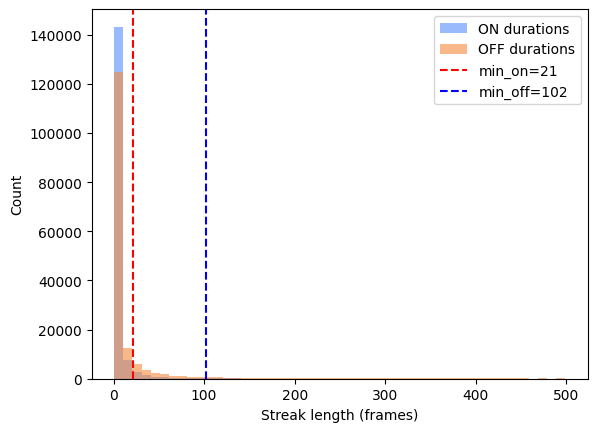

In [28]:
plt.hist(on_lengths, bins=50, alpha=0.6, label="ON durations")
plt.hist(off_lengths, bins=50, alpha=0.6, label="OFF durations")
plt.axvline(min_on, color='r', linestyle='--', label=f"min_on={min_on}")
plt.axvline(min_off, color='b', linestyle='--', label=f"min_off={min_off}")
plt.legend(); plt.xlabel("Streak length (frames)"); plt.ylabel("Count")
plt.show()

In [29]:
# --- τ prescan from debounced features (PCA + KMeans) ---
# 0) Debounce first (match the tree’s input)
# Increase min_on and min_off if the following test cannot pass the ck test
X_test = apply_hysteresis(X, min_on=21, min_off=21, traj_lengths=traj_lengths)

Applying hysteresis to all features (50 segments)...


In [30]:
import numpy as np
import pandas as pd


# =========================
# helpers
# =========================
def _binary_runs(seq):
    """
    Return list of runs:
    (value, start, end, length)
    end is exclusive
    """
    seq = np.asarray(seq).astype(int)
    runs = []
    if len(seq) == 0:
        return runs

    s = 0
    cur = seq[0]
    for i in range(1, len(seq)):
        if seq[i] != cur:
            runs.append((cur, s, i, i - s))
            s = i
            cur = seq[i]
    runs.append((cur, s, len(seq), len(seq) - s))
    return runs


def _collect_run_stats(raw, smooth, short_on_thr=3, short_off_thr=3):
    """
    Summarize how smoothing changed short vs long raw runs.
    """
    raw = np.asarray(raw).astype(int)
    smooth = np.asarray(smooth).astype(int)
    edited = (raw != smooth)

    runs = _binary_runs(raw)

    short_off_filled_frames = 0
    short_on_removed_frames = 0
    long_run_edited_frames = 0

    n_short_off_runs = 0
    n_short_off_runs_filled = 0
    n_short_on_runs = 0
    n_short_on_runs_removed = 0

    for val, s, e, L in runs:
        raw_seg = raw[s:e]
        smooth_seg = smooth[s:e]
        edited_seg = edited[s:e]

        if val == 0:
            if L <= short_off_thr:
                n_short_off_runs += 1
                if np.mean(smooth_seg == 1) > 0.5:
                    n_short_off_runs_filled += 1
                    short_off_filled_frames += L
            else:
                long_run_edited_frames += edited_seg.sum()

        else:  # val == 1
            if L <= short_on_thr:
                n_short_on_runs += 1
                if np.mean(smooth_seg == 0) > 0.5:
                    n_short_on_runs_removed += 1
                    short_on_removed_frames += L
            else:
                long_run_edited_frames += edited_seg.sum()

    return {
        "short_off_filled_frames": int(short_off_filled_frames),
        "short_on_removed_frames": int(short_on_removed_frames),
        "long_run_edited_frames": int(long_run_edited_frames),
        "n_short_off_runs": int(n_short_off_runs),
        "n_short_off_runs_filled": int(n_short_off_runs_filled),
        "n_short_on_runs": int(n_short_on_runs),
        "n_short_on_runs_removed": int(n_short_on_runs_removed),
    }


def _make_partial_revert_mask(raw, smooth, short_on_thr=3, short_off_thr=3):
    """
    Return a boolean mask of positions to revert back to raw
    for an ambiguous feature.

    Rule:
    - revert edited positions that lie on LONG raw runs
    - keep edited positions that lie on SHORT raw runs

    This preserves denoising of flicker while undoing edits that
    reshape longer dwell periods.
    """
    raw = np.asarray(raw).astype(int)
    smooth = np.asarray(smooth).astype(int)

    edited = (raw != smooth)
    revert_mask = np.zeros_like(edited, dtype=bool)

    runs = _binary_runs(raw)

    for val, s, e, L in runs:
        if val == 0:
            is_long = L > short_off_thr
        else:
            is_long = L > short_on_thr

        if is_long:
            revert_mask[s:e] |= edited[s:e]

    return revert_mask


def classify_feature_action(
    raw,
    smooth,
    T,
    short_on_thr=3,
    short_off_thr=3,
    pct_modified_thr=0.15,
    min_raw_support=0.02,
    max_occupancy_shift=0.15,
    safe_occupancy_shift=0.05,
    safe_helpful_ratio=0.70,
    max_long_run_damage=0.20,
    common_feature_raw_frac=0.10,
):
    """
    Classify a feature into:
    - keep_smoothed
    - partial_revert
    - full_revert
    """
    raw = np.asarray(raw).astype(int)
    smooth = np.asarray(smooth).astype(int)

    n_raw = int((raw == 1).sum())
    n_smooth = int((smooth == 1).sum())

    n_added = int(((raw == 0) & (smooth == 1)).sum())
    n_removed = int(((raw == 1) & (smooth == 0)).sum())
    n_total = n_added + n_removed
    pct_modified = n_total / T

    raw_frac = n_raw / T
    smooth_frac = n_smooth / T
    occupancy_shift = abs(smooth_frac - raw_frac)

    run_stats = _collect_run_stats(
        raw, smooth,
        short_on_thr=short_on_thr,
        short_off_thr=short_off_thr
    )

    helpful_edit_frames = (
        run_stats["short_off_filled_frames"] +
        run_stats["short_on_removed_frames"]
    )
    helpful_edit_ratio = helpful_edit_frames / max(n_total, 1)
    long_run_damage = run_stats["long_run_edited_frames"] / max(n_total, 1)

    # default
    action = "keep_smoothed"
    reason = "below_pct_threshold"

    # 1. low modification -> keep
    if pct_modified <= pct_modified_thr:
        action = "keep_smoothed"
        reason = "below_pct_threshold"

    else:
        # 2. clearly artificial / distorted -> full revert
        if raw_frac < min_raw_support and smooth_frac > raw_frac * 2:
            action = "full_revert"
            reason = "rare_feature_artificially_inflated"

        elif occupancy_shift > max_occupancy_shift:
            action = "full_revert"
            reason = "large_occupancy_shift"

        # 3. clearly safe cleanup -> keep
        elif helpful_edit_ratio >= safe_helpful_ratio and long_run_damage <= max_long_run_damage:
            action = "keep_smoothed"
            reason = "mostly_short_run_cleanup"

        # 4. common feature, overall occupancy stable, but mixed behavior -> partial revert
        elif raw_frac >= common_feature_raw_frac and occupancy_shift <= safe_occupancy_shift:
            action = "partial_revert"
            reason = "common_feature_small_occupancy_shift"

        # 5. mixed / suspicious -> partial revert
        elif long_run_damage > max_long_run_damage:
            action = "partial_revert"
            reason = "mixed_feature_long_run_damage"

        # 6. default ambiguous -> partial revert
        else:
            action = "partial_revert"
            reason = "ambiguous_partial_revert"

    out = {
        "raw_ON": n_raw,
        "smooth_ON": n_smooth,
        "added_fake_ON": n_added,
        "removed_true_ON": n_removed,
        "total_modified": n_total,
        "pct_modified": pct_modified,
        "raw_frac": raw_frac,
        "smooth_frac": smooth_frac,
        "occupancy_shift": occupancy_shift,
        "helpful_edit_ratio": helpful_edit_ratio,
        "long_run_damage": long_run_damage,
        "action_new": action,
        "reason_new": reason,
    }
    out.update(run_stats)
    return out


# =========================
# main analysis
# =========================
T, F = X.shape

# Suggested starting parameters
short_on_thr = 2
short_off_thr = 4
pct_modified_thr = 0.15
min_raw_support = 0.02
max_occupancy_shift = 0.15
safe_occupancy_shift = 0.05
safe_helpful_ratio = 0.70
max_long_run_damage = 0.20
common_feature_raw_frac = 0.10

results = []

for f in range(F):
    raw = X[:, f].astype(int)
    smooth = X_test[:, f].astype(int)

    row = classify_feature_action(
        raw=raw,
        smooth=smooth,
        T=T,
        short_on_thr=short_on_thr,
        short_off_thr=short_off_thr,
        pct_modified_thr=pct_modified_thr,
        min_raw_support=min_raw_support,
        max_occupancy_shift=max_occupancy_shift,
        safe_occupancy_shift=safe_occupancy_shift,
        safe_helpful_ratio=safe_helpful_ratio,
        max_long_run_damage=max_long_run_damage,
        common_feature_raw_frac=common_feature_raw_frac,
    )

    row["feature_idx"] = f
    row["feature_name"] = feature_names[f]
    row["revert_old"] = row["pct_modified"] > pct_modified_thr
    results.append(row)

df = pd.DataFrame(results)

# =========================
# build final hybrid matrix
# =========================
X_hybrid_partial = X_test.copy().astype(int)

n_keep = 0
n_partial = 0
n_full = 0

for f in range(F):
    raw = X[:, f].astype(int)
    smooth = X_test[:, f].astype(int)

    action = df.loc[f, "action_new"]

    if action == "keep_smoothed":
        n_keep += 1
        continue

    elif action == "full_revert":
        X_hybrid_partial[:, f] = raw
        n_full += 1

    elif action == "partial_revert":
        revert_mask = _make_partial_revert_mask(
            raw, smooth,
            short_on_thr=short_on_thr,
            short_off_thr=short_off_thr
        )
        X_hybrid_partial[revert_mask, f] = raw[revert_mask]
        n_partial += 1

    else:
        raise ValueError(f"Unknown action: {action}")

print("--- New hybrid summary ---")
print(f"keep_smoothed : {n_keep}")
print(f"partial_revert: {n_partial}")
print(f"full_revert   : {n_full}")

# =========================
# inspect the target feature
# =========================
target_interaction = "273-379:hbond"
specific_result = df[df["feature_name"] == target_interaction]

print("\n--- Specific Interaction Result ---")
if not specific_result.empty:
    print(specific_result.to_string(index=False))
else:
    print(f"Interaction '{target_interaction}' not found.")

# =========================
# compare old vs new
# =========================
print("\n--- Action counts ---")
print(df["action_new"].value_counts())

print("\n--- Old revert but new partial/keep ---")
df_old_vs_new = df[df["revert_old"] == True].copy()
print(
    df_old_vs_new.sort_values("pct_modified", ascending=False)[
        [
            "feature_idx", "feature_name",
            "pct_modified", "raw_frac", "smooth_frac",
            "helpful_edit_ratio", "long_run_damage",
            "action_new", "reason_new"
        ]
    ].head(40).to_string(index=False)
)

# Use this in downstream workflow
X = X_hybrid_partial

--- New hybrid summary ---
keep_smoothed : 1891
partial_revert: 25
full_revert   : 9

--- Specific Interaction Result ---
Interaction '273-379:hbond' not found.

--- Action counts ---
action_new
keep_smoothed     1891
partial_revert      25
full_revert          9
Name: count, dtype: int64

--- Old revert but new partial/keep ---
 feature_idx        feature_name  pct_modified  raw_frac  smooth_frac  helpful_edit_ratio  long_run_damage     action_new                           reason_new
        1310       398-664:hbond       0.59456   0.60656      0.03920            0.299112         0.700888    full_revert                large_occupancy_shift
         750       132-930:hbond       0.55816   0.58440      0.12720            0.355669         0.644188    full_revert                large_occupancy_shift
        1835       650-894:hbond       0.43336   0.52488      0.26088            0.394130         0.605778    full_revert                large_occupancy_shift
         410        96-384:hbond 

In [31]:
# Your residues of interest
important_residues = [115,118,121,124,127,130,133,182,185,188,191,194,197,381, 384, 387, 390, 393, 396, 399, 448, 451, 454, 457, 460, 463,647, 650, 653, 656, 659, 662, 665, 714, 717, 720, 723, 726, 729,913, 916, 919, 922, 925, 928, 931, 980, 983, 986, 989, 992, 995]

input_file = './data/contact_map_softcontacts.pkl'

# Run the loader
filtered_contacts = load_and_filter_contacts(input_file, important_residues)

# Verify
if filtered_contacts:
    print(f"Filtered contact count (frame 0): {len(filtered_contacts[0])}")
    # Example output: [(21, 150, 0.85), (21, 151, 0.44), ...]

Reading and filtering from: ./data/contact_map_softcontacts.pkl
Processed chunk 125 (Total frames: 25000)
Done. Loaded 25000 frames.
Filtered contact count (frame 0): 357


In [32]:
with open("./data/filtered_contacts.pkl", "wb") as f:
    pickle.dump(filtered_contacts, f)
print("Saved filtered contact map as filtered_contacts.pkl")

Saved filtered contact map as filtered_contacts.pkl


In [41]:
# Restore the data
with open("./data/filtered_contacts.pkl", "rb") as f:
    filtered_contacts = pickle.load(f)

print(f"Successfully loaded {len(filtered_contacts)} frames.")

Successfully loaded 33400 frames.


In [69]:
model = TemporalRuleTreeV6(
        lags=[4,5,6], # list of lag times
        alpha_vamp=0.5, # VAMP vs NMI weight
        min_pairs=2500, # minimum transition pairs per node
        min_leaf=2500, # minimum frames per leaf
        max_depth=5, # tree depth limit
        max_features_to_try=None, # try all features per split
        feature_types=feature_types, # feature type labels
        random_state=seed, # RNG seed
        # kinetic-aware parameters
        lag_mode="uniform", # emphasize the largest lag (40–60 → 60)
        tau_power=1.0, # used if lag_mode="power"
        lambda_row=0.7, # penalty weight for kinetically-similar children
        contact_frames=filtered_contacts,
        local_window=2,
        delta_mode='quantile',
        delta_quantile=0.6
        #delta_thresh=0.2
)

In [70]:
from temporal_rule_tree import seqsep_soft_weights
w_feat = seqsep_soft_weights(
    feature_names,
    min_sep=7,      # base threshold
    gamma=2.0,      # stronger penalty as sep gets smaller
    floor=0.15,     # never drop below 0.15 (to keep a faint chance)
    by_type={"hbond": 6, "salt_bridge": 5, "pi_pi": 8, "T_shape": 8, "cation_pi": 6}
)

In [71]:
# Set weights for different interactions
model.set_weights(feature_weights=w_feat,
                  type_weight_map={"hbond": 1.0,
                                   "salt_bridge": 1.5, 
                                   "pi_pi": 0.7, 
                                   "T_shape":0.5,
                                   "cation_pi":1.0})

In [72]:
# Train the model
model.fit(X, feature_names=feature_names, traj_lengths=traj_lengths)

Generating boundary-aware pairs for 50 trajectories.
[RankedGain D=0] 656-894:salt_bridge (VAMP=0.958, NMI=0.010) | RankScore=0.9284 * w=1.50 = Final=1.3925 | Best of 67 candidates.
  [Debug D=0] best=656-894:salt_bridge | VAMP_raw=0.958 NMI_raw=9.904e-03 sim_raw=0.021 | VAMP_pct=0.955 NMI_pct=0.985 sim_pct=0.060
[RankedGain D=1] 96-390:salt_bridge (VAMP=0.980, NMI=0.007) | RankScore=0.9138 * w=1.50 = Final=1.3707 | Best of 47 candidates.
  [Debug D=1] best=96-390:salt_bridge | VAMP_raw=0.980 NMI_raw=6.998e-03 sim_raw=0.010 | VAMP_pct=0.989 NMI_pct=0.883 sim_pct=0.032
[RankedGain D=2] 196-673:salt_bridge (VAMP=0.977, NMI=0.000) | RankScore=0.5273 * w=1.50 = Final=0.7909 | Best of 22 candidates.
  [Debug D=2] best=196-673:salt_bridge | VAMP_raw=0.977 NMI_raw=3.681e-04 sim_raw=0.011 | VAMP_pct=0.955 NMI_pct=0.227 sim_pct=0.091
[RankedGain D=1] 96-390:salt_bridge (VAMP=0.980, NMI=0.013) | RankScore=0.9642 * w=1.50 = Final=1.4462 | Best of 53 candidates.
[RankedGain D=2] 124-362:salt_bridg

In [73]:
# Save tree
os.makedirs('./output', exist_ok=True)
tree_dict = save_tree_json(model, "output/tree.json")

# Occupancy
occ = model.occupancy()

# Leaf assignments
labels = model.predict_leaf_ids(X)

Tree JSON saved to output/tree.json


In [74]:
# Check the output
print(f"T={X.shape[0]} frames, F={X.shape[1]} features, Leaves={occ.size}")
print("Top 10 leaf occupancies:", np.round(np.sort(occ)[::-1][:10], 4))
with open("output/tree.json") as f:
    tree = json.load(f)

T=25000 frames, F=1925 features, Leaves=7
Top 10 leaf occupancies: [0.2099 0.1689 0.1402 0.1371 0.1356 0.1081 0.1001]


In [75]:
# Features used in tree
split_features = collect_split_features(tree_dict, model)
print("Features driving splits:", split_features)

Features driving splits: ['656-894:salt_bridge', '96-390:salt_bridge', '196-673:salt_bridge', '96-390:salt_bridge', '124-362:salt_bridge', '311-605:salt_bridge']


In [76]:
import pandas as pd
import re

def renumber_pdb(pdb_input, excel_input, pdb_output):
    # 1. Load the numbering from Excel
    df = pd.read_excel(excel_input)
    # Assume Column 2 (index 1) contains the new indices
    raw_indices = df.iloc[:, 1].astype(str).tolist()

    # 2. Prepare the tetramer indices (Repeat the list 4 times)
    full_index_list = raw_indices * 4

    def parse_index(idx_str):
        """Splits '150a' into (' 150', 'a') for PDB format alignment."""
        match = re.match(r"(\d+)([a-zA-Z]?)", idx_str)
        if match:
            num = match.group(1)
            icode = match.group(2) if match.group(2) else " "
            return f"{num:>4}", icode
        return f"{idx_str:>4}", " "

    # 3. Process the PDB
    new_pdb_lines = []
    residue_count = -1
    last_res_id = None

    with open(pdb_input, 'r') as f:
        for line in f:
            if line.startswith(("ATOM", "HETATM")):
                # PDB fixed-width columns:
                # Residue Name: 17-20
                # Chain ID: 21
                # Res Sequence Number: 22-26
                # Insertion Code: 26 (0-indexed: 26)

                res_name = line[17:20].strip()
                chain_id = line[21]
                res_seq = line[22:26].strip()
                icode = line[26]

                # Create a unique ID for the current residue in the input file
                current_res_id = (chain_id, res_seq, icode)

                # If we hit a new residue, move to the next index in our Excel list
                if current_res_id != last_res_id:
                    residue_count += 1
                    last_res_id = current_res_id

                # Get the new index from our expanded list
                if residue_count < len(full_index_list):
                    new_num, new_icode = parse_index(full_index_list[residue_count])

                    # Construct the new line with updated numbering
                    # Columns 22-26: Sequence number (4 chars)
                    # Column 26 (0-indexed): Insertion code
                    line = line[:22] + new_num + new_icode + line[27:]

                new_pdb_lines.append(line)
            else:
                # Keep TER, END, CRYST1, etc. as they are
                new_pdb_lines.append(line)

    # 4. Write the output
    with open(pdb_output, 'w') as f:
        f.writelines(new_pdb_lines)

    print(f"Success! Processed {residue_count + 1} residues.")
    print(f"Output saved to: {pdb_output}")

# Run the function
renumber_pdb("./data/topology_fixed.pdb", "~/Downloads/L1_numbering.xlsx", "test.pdb")

Success! Processed 1078 residues.
Output saved to: test.pdb


In [77]:
def get_clean_mapping_dict(pdb_path, split_features):
    from Bio import PDB
    parser = PDB.PDBParser(QUIET=True)
    structure = parser.get_structure('protein', pdb_path)

    # 1. Build the index-to-residue list
    pdb_residues = []
    for model in structure:
        for chain in model:
            c_id = chain.get_id().strip()
            prefix = f"{c_id}:" if c_id else ""
            for residue in chain:
                # FIX: Check if it's a chain residue (not water/ligand)
                # residue.get_id()[0] is the hetero-flag. ' ' means it's an ATOM record.
                if residue.get_id()[0] == ' ':
                    res_num = residue.get_id()[1]
                    pdb_residues.append(f"{prefix}{res_num}")

    # 2. Create the dictionary
    mapping_dict = {}
    for feat in split_features:
        try:
            parts = feat.replace(':', '-').split('-')
            idx1, idx2, interaction = int(parts[0]), int(parts[1]), parts[2]

            new_name = f"{pdb_residues[idx1]}-{pdb_residues[idx2]} ({interaction})"
            mapping_dict[feat] = new_name
        except Exception as e:
            mapping_dict[feat] = feat

    return mapping_dict

# --- Workflow ---

# 1. Generate the mapping
rename_map = get_clean_mapping_dict("./test.pdb", split_features)
rename_map

{'656-894:salt_bridge': 'C:160-D:130 (salt_bridge)',
 '96-390:salt_bridge': 'A:130-B:160 (salt_bridge)',
 '196-673:salt_bridge': 'A:236-C:178 (salt_bridge)',
 '124-362:salt_bridge': 'A:160-B:130 (salt_bridge)',
 '311-605:salt_bridge': 'B:78-C:107 (salt_bridge)'}

### Step 3: Validation

#### Interaction Occupation
Note that the 'X' is the modified iput after applying hystersis. For accurate look up, please refer to the second dataframe calculated by 'X_raw'. The first dataframe serves as a sanity check to see whether the KinTree is splitting based on stable transitions rather than artificial noise or transient "flickering."

In [78]:
micro_labels = labels + 1
micro_labels

array([4, 4, 4, ..., 4, 4, 4], shape=(25000,))

In [79]:
presence_df = macro_feature_presence(
    X,
    feature_names,
    micro_labels,          # from collapse_labels after spectral lumping
    set(split_features)    # features used by your tree
)
presence_df = presence_df.rename(columns=rename_map)
display(presence_df)

,C:160-D:130 (salt_bridge),A:130-B:160 (salt_bridge),A:236-C:178 (salt_bridge),A:160-B:130 (salt_bridge),B:78-C:107 (salt_bridge)
Macro 0,0.0,0.0,0.00,0.00,0.00
Macro 1,100.0,100.0,61.55,47.63,64.60
Macro 2,100.0,0.0,100.00,89.50,76.02
Macro 3,100.0,0.0,0.00,47.67,50.29
Macro 4,0.0,100.0,67.55,10.92,75.15
Macro 5,0.0,0.0,45.35,100.00,45.42
Macro 6,0.0,0.0,34.45,0.00,100.00
Macro 7,0.0,0.0,37.88,0.00,0.00


In [80]:
X_raw, feature_names, feature_types = load_interaction_binary_pt(
    "./data/interaction.pt",
    use_types_separately=True,
    present_threshold=0.5
)

In [81]:
presence_df = macro_feature_presence(
    X_raw,
    feature_names,
    micro_labels,          # from collapse_labels after spectral lumping
    set(split_features)    # features used by your tree
)
presence_df = presence_df.rename(columns=rename_map)
display(presence_df)

,C:160-D:130 (salt_bridge),A:130-B:160 (salt_bridge),A:236-C:178 (salt_bridge),A:160-B:130 (salt_bridge),B:78-C:107 (salt_bridge)
Macro 0,0.00,0.00,0.00,0.00,0.00
Macro 1,83.46,92.56,58.53,39.42,61.07
Macro 2,85.01,1.81,95.97,86.46,71.15
Macro 3,87.91,4.78,3.45,42.39,46.76
Macro 4,4.12,91.03,61.07,22.81,73.32
Macro 5,4.57,0.78,41.84,88.18,42.77
Macro 6,6.16,4.36,30.42,6.27,82.21
Macro 7,6.73,1.52,38.22,6.81,10.51


### Step 4: Visualization
Here we provide Visualization functions to facilitate usage of our model. This includes:
1. Three styles tree visualization
2. A function to extract representative frames from the trajectory for futher visualization
3. A ready to use pml (pymol input) file to directly open in pymol for high quality visualization output.
4. An interactive interface to visualize structure and the tree

#### Tree Visualization

In [101]:
import json
import numpy as np
import plotly.express as px
import plotly.graph_objects as go

# 1. Data Loading
with open('output/tree.json', 'r') as f:
    tree_data = json.load(f)

# 2. Setup Coloring based strictly on leaf_id
# Helper function to scan the JSON and find all unique leaf IDs
def get_all_leaf_ids(node):
    if node.get("leaf"):
        return [node.get("leaf_id")]
    leaves = []
    if "left" in node: leaves.extend(get_all_leaf_ids(node["left"]))
    if "right" in node: leaves.extend(get_all_leaf_ids(node["right"]))
    return leaves

unique_leaves = np.sort(np.unique(get_all_leaf_ids(tree_data)))

colors_palette = px.colors.qualitative.Bold  # High contrast for papers
# Map colors directly to the leaf_id
leaf_color_map = {l: colors_palette[i % len(colors_palette)] for i, l in enumerate(unique_leaves)}

# Clear lists
ids, labels, parents, values, colors = [], [], [], [], []

def parse_node(node, parent_id=None, connection="ROOT"):
    node_id = str(id(node))
    val = node.get("n_frames", 1)

    # Format the Connection Label
    path_info = ""
    if connection == "PRESENT":
        path_info = "<i>Yes:</i><br>"
    elif connection == "ABSENT":
        path_info = "<i>No:</i><br>"

    if not node.get("leaf"):
        raw_rule = node.get("rule", {}).get("name", "Split")
        rule_name = rename_map.get(raw_rule, raw_rule)
        display_label = f"{path_info}<b>{rule_name}?</b>"
        node_color = "rgb(245, 245, 245)"
    else:
        # We are completely ignoring macrostates here. Just using leaf_id.
        leaf_id = node.get("leaf_id")

        # 1-based indexing in the plot cells
        display_label = f"{path_info}<b>Leaf {leaf_id + 1}</b>"
        node_color = leaf_color_map[leaf_id]

    ids.append(node_id)
    labels.append(display_label)
    parents.append(parent_id)
    values.append(val)
    colors.append(node_color)

    if "left" in node:
        parse_node(node["left"], node_id, connection="PRESENT")
    if "right" in node:
        parse_node(node["right"], node_id, connection="ABSENT")

# Parse the tree
parse_node(tree_data)

# 3. Create Icicle Plot
fig = go.Figure()

fig.add_trace(go.Icicle(
    ids=ids,
    labels=labels,
    parents=parents,
    values=values,
    branchvalues="total",
    marker=dict(colors=colors, line=dict(color='white', width=1.5)),
    tiling=dict(orientation='v'),
    pathbar=dict(visible=True)
))

# 4. Final Styling
fig.update_layout(
    title=dict(
        text="Structural Path to Leaf Node Classification",
        y=0.95,
        x=0.05,
        xanchor='left'
    ),
    font=dict(size=20),
    template="plotly_white",
    xaxis=dict(visible=False),
    yaxis=dict(visible=False),
    showlegend=False,
    margin=dict(t=60, l=10, r=10, b=10),
)

# 5. Show the figure
fig.show(config={'displayModeBar': False})

In [103]:
# --- Update the font sizes before saving ---
fig.update_layout(
    font=dict(size=22),  # Global font (Pathbar, etc.)
    title=dict(font=dict(size=30))  # Specific title size
)

# Update the labels inside the Icicle boxes
fig.update_traces(textfont_size=24)

# --- Now Save ---
fig.write_image("output/tree_publication_quality.pdf", width=1500, height=600)
fig.write_image("output/tree_high_res.png", width=1500, height=600, scale=3)

In [102]:
# 2. Save as a Vector PDF (Crisp text, no pixels)
fig.write_image("output/tree_publication_quality.pdf", width=1500, height=600)

# 3. Save as a High-Res PNG (if you absolutely need an image)
fig.write_image("output/tree_high_res.png", width=1500, height=600, scale=4)

fig.write_html("output/tree_.html")

# 4. Optional: Put the button back if you are still working in the notebook
# (Refer back to your original updatemenus code)

In [84]:
import json
import numpy as np
import plotly.express as px
import plotly.graph_objects as go

# 1. Data Loading
with open('output/tree.json', 'r') as f:
    tree_data = json.load(f)

# 2. Setup Coloring based strictly on leaf_id
# Helper function to scan the JSON and find all unique leaf IDs
def get_all_leaf_ids(node):
    if node.get("leaf"):
        return [node.get("leaf_id")]
    leaves = []
    if "left" in node: leaves.extend(get_all_leaf_ids(node["left"]))
    if "right" in node: leaves.extend(get_all_leaf_ids(node["right"]))
    return leaves

unique_leaves = np.sort(np.unique(get_all_leaf_ids(tree_data)))

colors_palette = px.colors.qualitative.D3
# Map colors directly to the leaf_id
leaf_color_map = {l: colors_palette[i % len(colors_palette)] for i, l in enumerate(unique_leaves)}

def parse_node(node, parent_id=None, connection="ROOT"):
    node_id = str(id(node))
    val = node.get("n_frames", 1)

    # 1. Fix the "If Yes/No" logic to refer to the branch taken
    path_info = ""
    if connection == "PRESENT":
        path_info = "<i>Yes:</i><br>"
    elif connection == "ABSENT":
        path_info = "<i>No:</i><br>"

    if not node.get("leaf"):
        # 2. Renumber the feature
        raw_rule = node.get("rule", {}).get("name", "Split")
        rule_name = rename_map.get(raw_rule, raw_rule)

        display_label = f"{path_info}<b>{rule_name}?</b>"
        # 3. Clean structural color (Light Grey for decision nodes)
        node_color = "rgb(240, 240, 240)"
    else:
        # Leaf nodes (No more macrostate mapping here)
        leaf_id = node.get("leaf_id")

        # 1-based indexing in the plot cells
        display_label = f"{path_info}<b>Leaf {leaf_id+1}</b>"
        node_color = leaf_color_map[leaf_id]

    ids.append(node_id)
    labels.append(display_label)
    parents.append(parent_id)
    values.append(val)
    colors.append(node_color)

    if "left" in node:
        parse_node(node["left"], node_id, connection="PRESENT")
    if "right" in node:
        parse_node(node["right"], node_id, connection="ABSENT")

# Clear and parse
ids, labels, parents, values, colors = [], [], [], [], []
parse_node(tree_data)

# 4. Create the Treemap with larger font and crisp lines
fig = go.Figure(go.Treemap(
    ids=ids,
    labels=labels,
    parents=parents,
    values=values,
    branchvalues="total",
    marker=dict(
        colors=colors,
        line=dict(color='white', width=2)
    ),
    # Use 'textinfo' and 'textfont' to fix the small font issue
    textinfo="label",
    textfont=dict(size=18),
    hovertemplate='<b>%{label}</b><br>Frames: %{value}<extra></extra>'
))

fig.update_layout(
    title="Structural Hierarchy Treemap",
    template="plotly_white",
    margin=dict(t=50, l=10, r=10, b=10)
)

fig.show(config={'displayModeBar': False})

In [85]:
# 2. Save as a Vector PDF (Crisp text, no pixels)
fig.write_image("output/treemap.pdf", width=1500, height=600)

# 3. Save as a High-Res PNG (if you absolutely need an image)
fig.write_image("output/treemap.png", width=1500, height=600, scale=4)

fig.write_html("output/treemap.html")

# 4. Optional: Put the button back if you are still working in the notebook
# (Refer back to your original updatemenus code)

In [4]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import networkx as nx
import itertools
import json
from matplotlib.patches import Patch

# ---------- 1. Build the tree ----------
# Assuming rename_map is already created from the PDB file
# rename_map = get_clean_mapping_dict("structure.pdb", split_features)

def tree_to_graph(tree):
    G = nx.DiGraph()
    counter = itertools.count()

    def dfs(node):
        node_id = next(counter)
        is_leaf = node.get("leaf", False)

        if is_leaf:
            # Get Macrostate ID instead of just Leaf ID for better info
            m_id = [1,2,3,4,5,6,7]
            label = f"Macro {m_id}"
            polarity = None
        else:
            rule = node.get("rule", {})
            raw_name = rule.get("name", "split")

            # --- MAPPING BACK TO PDB INDEX ---
            # We look up the raw name in our dictionary
            label = rename_map.get(raw_name, raw_name)

            polarity = rule.get("polarity_left_is_present", 1)

        G.add_node(
            node_id,
            label=label,
            leaf=is_leaf,
            leaf_id=node.get("leaf_id", -1),
            polarity=polarity,
        )

        if not is_leaf:
            left = node.get("left")
            right = node.get("right")
            if left is not None:
                left_id = dfs(left)
                branch_label = "Yes" if polarity == 1 else "No"
                G.add_edge(node_id, left_id, branch=branch_label)
            if right is not None:
                right_id = dfs(right)
                branch_label = "No" if polarity == 1 else "Yes"
                G.add_edge(node_id, right_id, branch=branch_label)
        return node_id

    dfs(tree)
    return G


# ---------- 2. Layout ----------
def hierarchy_pos_lr(G, root=None, width=1.0, vert_gap=0.25, vert_loc=0, xcenter=0.5):
    if root is None:
        root = list(G.nodes)[0]
    children = list(G.successors(root))
    if not children:
        return {root: (vert_loc, xcenter)}
    dx = width / len(children)
    nextx = xcenter - width / 2 - dx / 2
    pos = {root: (vert_loc, xcenter)}
    for child in children:
        nextx += dx
        pos.update(
            hierarchy_pos_lr(
                G,
                child,
                width=dx,
                vert_gap=vert_gap,
                vert_loc=vert_loc + vert_gap,
                xcenter=nextx,
            )
        )
    return pos

In [5]:
with open('output/tree.json', 'r') as f:
    tree_dict = json.load(f)

G = tree_to_graph(tree_dict)

# (Assuming G is already created via G = tree_to_graph(tree_dict))

# 1. Dynamically find the number of leaves for the colormap
leaf_ids = [d["leaf_id"] for n, d in G.nodes(data=True) if d.get("leaf")]
n_leaves = int(np.max(leaf_ids)) + 1 if leaf_ids else 0

# Using Paired colormap scaled to the number of leaves
cmap = cm.get_cmap("Paired", n_leaves)

node_colors = []
for n, d in G.nodes(data=True):
    if d.get("leaf"):
        leaf_id = int(d["leaf_id"])
        node_colors.append(cmap(leaf_id))
    else:
        node_colors.append((0.8, 0.8, 0.8, 1.0)) # Light grey for decision nodes

# ---------- 4. Refined Plotting ----------
fig, ax = plt.subplots(figsize=(20, 18))
pos = hierarchy_pos_lr(G, width=5.0, vert_gap=0.3) # Layout coordinates

# Draw edges first
nx.draw_networkx_edges(G, pos, arrows=True, arrowstyle='->', arrowsize=15, edge_color="gray", alpha=0.5)

# Draw rectangular nodes with labels
for node, (x, y) in pos.items():
    data = G.nodes[node]

    # --- UPDATE START: Strictly use leaf_id with 1-based labeling ---
    if data.get("leaf"):
        leaf_id = int(data["leaf_id"])
        facecolor = cmap(leaf_id)
        display_label = f"Leaf {leaf_id + 1}"
    else:
        facecolor = (0.95, 0.95, 0.95)
        display_label = data.get("label", "Node") # Keep "Rule?" labels as they are
    # --- UPDATE END ---

    ax.text(x, y, display_label,
            size=20,
            fontweight='bold',
            va="center", ha="center",
            bbox=dict(boxstyle="round,pad=0.5",
                      facecolor=facecolor,
                      edgecolor='black',
                      alpha=1.0))

# Edge labels (Yes/No)
edge_labels = nx.get_edge_attributes(G, 'branch')
nx.draw_networkx_edge_labels(
    G, pos,
    edge_labels=edge_labels,
    font_color="darkorange",
    font_size=18,
    font_weight='bold',
    rotate=False,
    label_pos=0.6,
    bbox=dict(facecolor='white', edgecolor='none', alpha=0.7)
)

# ---------- 5. Final Formatting ----------
# Legend removed to match the style of the interactive plots

# Title updated to reflect Leaf Nodes instead of Macrostates
plt.title("Temporal Rule Tree: Feature Interactions & Leaf Nodes", fontsize=24, pad=30)
plt.axis("off")
plt.tight_layout()

# Save as high-res PNG
plt.savefig('output/tree.png', dpi=600)
plt.show()

NameError: name 'rename_map' is not defined

#### Extract frames for visualization

In [94]:
import numpy as np

# Extract frames for visualization based strictly on Leaf IDs
rng = np.random.default_rng(seed=42)  # set seed for reproducibility

# Ensure your input array of leaf assignments is a numpy array
# (Replace 'leaf_labels' with whatever your frame-to-leaf array is named)
leaf_labels = np.asarray(micro_labels)
unique_leaves = np.unique(micro_labels)

samples_per_leaf = 100
selected_frames = {}

for leaf in unique_leaves:
    # Find all frames that belong to this specific leaf
    frame_indices = np.where(leaf_labels == leaf)[0]

    # Handle cases where a leaf has very few frames
    if len(frame_indices) < samples_per_leaf:

        # Option A: Strict error (Your original approach)
        raise ValueError(
            f"Leaf {leaf} has only {len(frame_indices)} frames, "
            f"cannot sample {samples_per_leaf} without replacement."
        )

        # Option B: Relaxed approach (Highly Recommended)
        # If there aren't enough frames, just take all the ones that exist.
        # To use this, comment out the ValueError above and uncomment the line below:
        # chosen = frame_indices

    else:
        # Randomly select the exact number of frames
        chosen = rng.choice(
            frame_indices,
            size=samples_per_leaf,
            replace=False
        )

    # Store the sorted indices so your extracted trajectory remains in chronological order
    selected_frames[leaf] = np.sort(chosen)

In [95]:
selected_frames

{np.int64(1): array([ 4151,  4219,  4234,  4265,  4293,  4304,  4316,  4321,  4339,
         4438,  4452,  4489,  6090,  6116,  6125,  6181,  6214,  6229,
         6244,  6337,  6346,  6539,  6653,  6709,  7231,  7271,  7290,
         7363,  7398,  7411,  7426,  7496,  8246,  8291,  8342,  8361,
         9030,  9032,  9033,  9047,  9052,  9057,  9119,  9123,  9141,
         9165,  9223,  9231,  9265,  9307,  9382,  9401,  9481, 11797,
        19558, 19580, 19591, 19613, 19716, 19724, 19749, 19762, 19771,
        19773, 19798, 19827, 19836, 19897, 19957, 19964, 19985, 19995,
        20709, 20720, 20764, 20766, 20772, 20773, 20849, 20898, 20908,
        20933, 20959, 20989, 20992, 21542, 21558, 21568, 21668, 21697,
        21757, 21791, 21811, 21946, 22502, 22518, 22525, 22636, 22668,
        22672]),
 np.int64(2): array([ 1565,  1577,  1640,  1721,  1765,  1782,  1784,  1819,  1822,
         1850,  1927,  7043,  7060,  7086,  7121,  7149,  7164,  7177,
         7207,  7565,  7759,  7766

In [96]:
trajectory = "./Aligned.xtc"
trajectory

'./Aligned.xtc'

In [97]:
from MDAnalysis.coordinates.XTC import XTCWriter

u = mda.Universe(topology, trajectory)
for cluster_id, frames in selected_frames.items():
    out_xtc = f"./output/leaf{cluster_id}_100frames.xtc"

    with XTCWriter(out_xtc, n_atoms=u.atoms.n_atoms) as W:
        for ts in u.trajectory[frames]:
            W.write(u.atoms)

    print(f"Wrote {out_xtc}")

Wrote ./output/leaf1_100frames.xtc
Wrote ./output/leaf2_100frames.xtc
Wrote ./output/leaf3_100frames.xtc
Wrote ./output/leaf4_100frames.xtc
Wrote ./output/leaf5_100frames.xtc
Wrote ./output/leaf6_100frames.xtc
Wrote ./output/leaf7_100frames.xtc


#### Create PML file for pymol

In [98]:
import re
from collections import defaultdict
import MDAnalysis as mda

FEATURE_RE = re.compile(r"^(?P<i>\d+)-(?P<j>\d+):(?P<itype>.+)$")

def _safe_token(x: str) -> str:
    return str(x).strip().replace(" ", "_").replace("-", "_").replace(":", "_")

def _resi_with_icode(res) -> str:
    """
    Return PyMOL-compatible resi string including insertion code if present.
    """
    resid = str(res.resid)
    icode = getattr(res, "icode", "")
    if icode and str(icode).strip() and str(icode).strip() != " ":
        return f"{resid}{str(icode).strip()}"
    return resid

def _infer_id_field(u: mda.Universe, prefer: str = "auto") -> str:
    """
    Decide whether to use PyMOL 'chain' or 'segi'.

    Heuristic:
    - If most chainIDs are 1 character -> chain
    - else if segids exist -> segi
    - else -> chain

    prefer can be: "auto", "chain", "segi"
    """
    prefer = (prefer or "auto").lower()
    if prefer in ("chain", "segi"):
        return prefer

    chain_vals = []
    segi_vals = []
    for res in u.residues:
        chain = getattr(res, "chainID", "") or ""
        segi  = getattr(res, "segid", "") or ""
        chain_vals.append(str(chain).strip())
        segi_vals.append(str(segi).strip())

    chain_nonempty = [c for c in chain_vals if c]
    segi_nonempty  = [s for s in segi_vals if s]

    if chain_nonempty:
        one_char_ratio = sum(len(c) == 1 for c in chain_nonempty) / len(chain_nonempty)
        if one_char_ratio >= 0.6:
            return "chain"

    if segi_nonempty:
        return "segi"

    return "chain"

def _sel_term(id_field: str, id_value: str, resi: str) -> str:
    """
    Build a PyMOL selection term for one residue:
      (chain A and resi 123)   or   (segi P0 and resi 123)
    If id_value is empty, fall back to (resi 123).
    """
    id_field = id_field.lower()
    id_value = str(id_value).strip()
    if id_value:
        return f"({id_field} {id_value} and resi {resi})"
    return f"(resi {resi})"

def _pml_name_for_feature(i: int, j: int, itype: str) -> str:
    return f"sf_{i}_{j}_{_safe_token(itype)}"

def write_tree_split_pml(
    split_features,
    pdb_path,
    out_pml="tree_split_pairs.pml",
    out_tsv="tree_split_pairs.tsv",
    object_name="holo",

    # Robustness / overrides
    id_field="auto",           # "auto" (recommended), or "chain", or "segi"

    # Visualization options
    label_pairs=True,          # label residues by resn+resi (PDB)
    label_field="CA",          # typically "CA" for protein; if missing, set to None to label all atoms
    color_by_type=True,
    background="white",
    cartoon_transparency=0.15,
    stick_radius=0.18,
):
    """
    Always selects BOTH endpoints (i and j) for every feature.
    Works for holo (protein-ligand) and apo (protein-protein) without any special cases.
    """

    u = mda.Universe(pdb_path)
    id_field_used = _infer_id_field(u, prefer=id_field)

    # Parse features into rows and group by type
    rows = []
    rows_by_type = defaultdict(list)

    for feat in split_features:
        m = FEATURE_RE.match(feat)
        if not m:
            raise ValueError(f"Unrecognized feature format: {feat} (expected 'i-j:type')")

        i = int(m.group("i"))
        j = int(m.group("j"))
        itype = m.group("itype").strip()

        rows.append((feat, i, j, itype))
        rows_by_type[itype].append((feat, i, j, itype))

    # Map residue index -> (id_value, resi, resn)
    def idx_to_terms(idx: int):
        res = u.residues[idx]
        if id_field_used == "chain":
            id_value = getattr(res, "chainID", "") or ""
        else:
            id_value = getattr(res, "segid", "") or ""
        id_value = str(id_value).strip()
        resi = _resi_with_icode(res)
        resn = str(res.resname).strip()
        return id_value, resi, resn

    # Write TSV legend (one line per feature, with both endpoints)
    with open(out_tsv, "w") as f:
        f.write(
            "feature\tinteraction\t"
            "model_i\tmodel_j\t"
            f"{id_field_used}_i\tresi_i\tresn_i\t"
            f"{id_field_used}_j\tresi_j\tresn_j\n"
        )
        for feat, i, j, itype in rows:
            i_id, i_resi, i_resn = idx_to_terms(i)
            j_id, j_resi, j_resn = idx_to_terms(j)
            f.write(
                f"{feat}\t{itype}\t"
                f"{i}\t{j}\t"
                f"{i_id}\t{i_resi}\t{i_resn}\t"
                f"{j_id}\t{j_resi}\t{j_resn}\n"
            )

    # Simple palette for interaction types (fallback is yellow)
    type_color_map = {
        "hbond": "yellow",
        "pi_pi": "cyan",
        "cation_pi": "magenta",
        "t-shape": "cyan",
        "t_shape": "cyan",
        "salt_bridge": "orange",
        "disulfide": "green",
    }

    # Emit PML
    all_feature_sel_names = []

    with open(out_pml, "w") as p:
        p.write("# Auto-generated PyMOL script: Tree split-driving pairs\n")
        p.write("reinitialize\n")
        p.write(f'load "{pdb_path}", {object_name}\n\n')

        p.write("hide everything\n")
        p.write(f"show cartoon, {object_name}\n")
        p.write(f"color gray80, {object_name}\n")
        p.write(f"set cartoon_transparency, {cartoon_transparency}\n\n")

        p.write("# Debug helpers (uncomment if selections are empty)\n")
        p.write(f"# print cmd.get_chains('{object_name}')\n")
        p.write(f"# print cmd.get_segis('{object_name}')\n")
        p.write(f"# iterate ({object_name} and name CA), print(chain, segi, resn, resi)\n\n")

        p.write(f"# Using PyMOL id_field = {id_field_used} (user requested: {id_field})\n\n")

        p.write("set label_size, 18\n")
        p.write("set label_color, black\n\n")

        # Per-feature selections grouped by interaction type
        for itype in sorted(rows_by_type.keys()):
            group_name = f"splits_{_safe_token(itype)}"
            p.write(f"# === {itype} ===\n")

            for feat, i, j, itype in rows_by_type[itype]:
                i_id, i_resi, _ = idx_to_terms(i)
                j_id, j_resi, _ = idx_to_terms(j)

                term_i = _sel_term(id_field_used, i_id, i_resi)
                term_j = _sel_term(id_field_used, j_id, j_resi)

                sel_name = _pml_name_for_feature(i, j, itype)
                all_feature_sel_names.append(sel_name)

                # Pair selection: always both endpoints
                p.write(f"select {sel_name}, ({term_i}) or ({term_j})\n")
                p.write(f"show sticks, {sel_name}\n")
                p.write(f"group {group_name}, {sel_name}\n")

                # Labels: resn+resi (PDB-based). Usually CA for protein.
                if label_pairs:
                    if label_field:
                        p.write(f'label {sel_name} and name {label_field}, "%s%s" % (resn, resi)\n')
                    else:
                        p.write(f'label {sel_name}, "%s%s" % (resn, resi)\n')

                p.write("\n")

            # Color the whole group by interaction type
            if color_by_type:
                key = itype.strip()
                key2 = key.lower().replace(" ", "_")
                color = type_color_map.get(key, type_color_map.get(key2, "yellow"))
                p.write(f"color {color}, {group_name}\n\n")

            p.write("\n")

        # Combined selection
        if all_feature_sel_names:
            p.write(f"select split_all, {' or '.join(all_feature_sel_names)}\n")
        else:
            p.write("select split_all, none\n")

        p.write(f"set stick_radius, {stick_radius}, split_all\n")
        p.write("zoom split_all, 12\n")
        p.write(f"bg_color {background}\n")

    return {
        "out_pml": out_pml,
        "out_tsv": out_tsv,
        "id_field_used": id_field_used,
        "n_features": len(rows),
    }

In [99]:
info = write_tree_split_pml(
    split_features=split_features,
    pdb_path='./test.pdb',     # adjust if needed
    id_field="auto",           # or "segi" if your PDB uses segids like P0
    label_pairs=True,
    label_field="CA",          # if you want to label ligand too, set label_field=None (more clutter)
    color_by_type=True,
)

print("Generated:", info["out_pml"], info["out_tsv"])
print("Using id_field:", info["id_field_used"])
print("Features:", info["n_features"])

Generated: tree_split_pairs.pml tree_split_pairs.tsv
Using id_field: segi
Features: 6
